In [1]:
import pandas as pd
import numpy as np

# loading PubChemfingerprint file of EZH2 data

In [3]:
df = pd.read_csv('EZH2_Active_Inactive_data.csv')
df

C:\Users\krish\AppData\Local\Temp\ipykernel_28888\1802110413.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('EZH2_Active_Inactive_data.csv')


,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,bioactivity_class
0,CHEMBL3929944,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
1,CHEMBL3397330,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
2,CHEMBL3605458,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
3,CHEMBL3605454,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
4,CHEMBL3605443,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11562,C96398094,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11563,C96927198,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11564,C65265984,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11565,C20744856,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive


In [5]:
df['bioactivity_class'].value_counts()

bioactivity_class
inactive    9589
active      1978
Name: count, dtype: int64

In [7]:
w = df.drop('bioactivity_class', axis=1)
y = df.bioactivity_class
x = w.drop('Name', axis=1)

In [9]:
names = df['Name']  # Keeping the names here for later reference

In [11]:
y.replace(('active', 'inactive',),(1,0), inplace=True)
y

C:\Users\krish\AppData\Local\Temp\ipykernel_28888\601137051.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace(('active', 'inactive',),(1,0), inplace=True)


0        1
1        0
2        1
3        1
4        1
        ..
11562    0
11563    0
11564    0
11565    0
11566    0
Name: bioactivity_class, Length: 11567, dtype: int64

# variance based feature selection

In [13]:
from sklearn.feature_selection import VarianceThreshold

def remove_low_variance(input_data, threshold=0.1):
    selection = VarianceThreshold(threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices=True)]]

x = remove_low_variance(x, threshold=0.1)
x

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP37,PubchemFP43,PubchemFP143,...,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
0,0,0,0,0,0,0,0,1,0,1,...,1,0,0,1,0,0,1,0,0,0
1,1,0,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,0,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,1,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11562,0,0,1,0,0,0,0,0,0,1,...,1,0,0,0,0,1,0,0,1,0
11563,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
11564,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
11565,0,0,0,0,0,1,0,0,0,1,...,0,1,0,0,1,0,0,0,0,1


In [14]:
x.to_csv('pubchem_reduced_fingerprint.csv', index = False) 
# Load the CSV files into DataFrames
df1 = pd.read_csv('pubchem_reduced_fingerprint.csv')

# loading a screening library into a dataframe

In [17]:
#Maybridge_screening_library
molecule_library_df = pd.read_csv('maybridge_pubchemfingerprints.csv') #instead of maybridge_pubchemfingerprints, one can call their preffered liberary for screen
molecule_library_df

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AC10018,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AC10402,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AC10608,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AC10702,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AC10751,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55711,XBX00331,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55712,XBX00332,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55713,XBX00337,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55714,XBX00342,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
screen_df = molecule_library_df.drop('Name', axis=1)
screen_df.to_csv('maybridge_withoutname_pubfingerprint.csv', index = False)
df2 = pd.read_csv('maybridge_withoutname_pubfingerprint.csv')

In [21]:
# Get the list of columns in df1
columns_csv1 = set(df1.columns)

In [23]:
# Extraction of variance based features identical to our EZH2 curated dataset
matching_columns = [col for col in df2.columns if col in columns_csv1]

In [25]:
# Create a new DataFrame with only the matching columns
df2_filtered = df2[matching_columns]
df2_filtered
df2_filtered.to_csv('maybridge_reduced_2_pubfingerprint.csv', index = False)

# External dataset processing.

In [26]:
ext_data = pd.read_csv('external_dataset_descriptor.csv') 
ext_data['bioactivity_class'].value_counts()

bioactivity_class
inactive    680
active       20
Name: count, dtype: int64

In [28]:
w1 = ext_data.drop('bioactivity_class', axis=1)
y1 = ext_data.bioactivity_class
x1 = w1.drop('Name', axis=1)

In [31]:
y1.replace(('active', 'inactive',),(1,0), inplace=True)
y1

C:\Users\krish\AppData\Local\Temp\ipykernel_28888\4166126559.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y1.replace(('active', 'inactive',),(1,0), inplace=True)


0      1
1      1
2      1
3      1
4      1
      ..
695    0
696    0
697    0
698    0
699    0
Name: bioactivity_class, Length: 700, dtype: int64

In [33]:
ext_data.to_csv('externaldata_withoutname_fingerprints.csv', index = False)
# Load the CSV files into DataFrames
df1 = pd.read_csv('pubchem_reduced_fingerprint.csv')
df3 = pd.read_csv('externaldata_withoutname_fingerprints.csv')
# Get the list of columns in df1
columns_csv1 = set(df1.columns)
# Extract columns from CSV_2 that also exist in df3
matching_column = [col for col in df3.columns if col in columns_csv1]
# Create a new DataFrame with only the matching columns
df3_filtered = df3[matching_column]
df3_filtered

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP37,PubchemFP43,PubchemFP143,...,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
0,1,0,1,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
1,1,0,1,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
2,1,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
3,1,0,1,1,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
4,1,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,1,1,0,1,0,0,0,0,0,1,...,0,0,0,1,1,0,0,0,0,0
696,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
697,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
698,0,0,1,1,0,1,0,0,0,1,...,0,1,1,0,1,0,0,0,0,1


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=.3,random_state =42)

In [39]:
x_train.shape

(8096, 263)

In [41]:
x_test.shape

(3471, 263)

# saving a CSV file of training and test set

In [43]:
# Create a results table for your test set
train_names = names.loc[x_train.index] # This gets names for only the test rows
results = pd.DataFrame({
    'Molecule_Name': train_names,
    'Actual': y_train,
    #'Predicted': svm_tuned_pred
})

print(results.head())

      Molecule_Name  Actual
4972      C63655273       0
4148      C10736994       0
1400       50096906       1
5478      C14006018       0
11117     C57293376       0


In [45]:
train_names.to_csv('train_set_names.csv', index = False)
train_names

4972     C63655273
4148     C10736994
1400      50096906
5478     C14006018
11117    C57293376
           ...    
11284    C33032335
5191     C14123419
5390     C35484492
860         190209
7270     C08450492
Name: Name, Length: 8096, dtype: object

In [47]:
# Create a results table for your test set
test_names = names.loc[x_test.index] # This gets names for only the test rows
results = pd.DataFrame({
    'Molecule_Name': test_names,
    'Actual': y_test,
    #'Predicted': svm_tuned_pred
})

print(results.head())

     Molecule_Name  Actual
9775     C23249358       0
8813     C03104708       0
4702     C09410847       0
5027     C83311341       0
9620     C12950930       0


In [49]:
test_names.to_csv('test_set_names.csv', index = False)
test_names

9775        C23249358
8813        C03104708
4702        C09410847
5027        C83311341
9620        C12950930
            ...      
7382        C21037877
6618        C72414803
3973        C34864600
6672        C04522421
538     CHEMBL5093442
Name: Name, Length: 3471, dtype: object

In [51]:
# Convert to same type and verify
df_all = pd.read_csv('EZH2_smiles_data.csv')
print((df_all['name'].astype(str).values == df['Name'].astype(str).values).all())

True


In [53]:
# Create mapping: df gapped index -> df_all clean index
index_map = dict(zip(df.index, df_all.index))

# Map x_train and x_test indices
train_mapped = [index_map[i] for i in x_train.index]
test_mapped = [index_map[i] for i in x_test.index]

ezh2_train_set = df_all.loc[train_mapped]
ezh2_test_set = df_all.loc[test_mapped]

print(f"x_train: {len(x_train)} | Train CSV: {len(ezh2_train_set)}")
print(f"x_test: {len(x_test)} | Test CSV: {len(ezh2_test_set)}")

# Save
ezh2_train_set.to_csv('EZH2_train_set.csv', index=False)
ezh2_test_set.to_csv('EZH2_test_set.csv', index=False)

x_train: 8096 | Train CSV: 8096
x_test: 3471 | Test CSV: 3471


In [55]:
ezh2_train_set['bioactivity_class'].value_counts()

bioactivity_class
inactive    6722
active      1374
Name: count, dtype: int64

In [57]:
ezh2_test_set['bioactivity_class'].value_counts()

bioactivity_class
inactive    2867
active       604
Name: count, dtype: int64

In [59]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [61]:
# Initialize classifiers
svm = SVC()
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
knn = KNeighborsClassifier()

# Hyperparameter tuning for SVM

In [63]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [67]:
# Define the parameter grid to search
param_grid = {
    'kernel': ['linear','sigmoid'],  # Types of kernels to try
    'C': [0.1, 10, 100],  # Values of C to try
    'gamma': ['auto', 0.0001, 0.001],  # Values of gamma to try 
}

In [69]:
# Create GridSearchCV object
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)
#(estimator=svm_classifier is already been called above)

In [71]:
#Perform hyperparameter tuning
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   1.0s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   1.0s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.8s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.8s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.7s
[CV] END ..................C=0.1, gamma=auto, kernel=sigmoid; total time=   4.0s
[CV] END ..................C=0.1, gamma=auto, kernel=sigmoid; total time=   4.3s
[CV] END ..................C=0.1, gamma=auto, kernel=sigmoid; total time=   4.3s
[CV] END ..................C=0.1, gamma=auto, kernel=sigmoid; total time=   3.8s
[CV] END ..................C=0.1, gamma=auto, kernel=sigmoid; total time=   3.9s
[CV] END .................C=0.1, gamma=0.0001, kernel=linear; total time=   0.6s
[CV] END .................C=0.1, gamma=0.0001, k

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 10, ...], 'gamma': ['auto', 0.0001, ...], 'kernel': ['linear', 'sigmoid']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [73]:
# Print best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'sigmoid'}


In [75]:
# Get the best model
best_svm = grid_search.best_estimator_

In [77]:
best_svm = SVC(kernel = 'sigmoid', C = 100, gamma = 0.001) #hypertuned parameter based on grid search

In [79]:
best_svm.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [81]:
# Evaluate the best model
svm_tuned_pred = best_svm.predict(x_test)
svm_tuned_accuracy = accuracy_score(y_test, svm_tuned_pred)
from sklearn.metrics import classification_report
svm_report = classification_report(y_test, svm_tuned_pred)

In [83]:
# Print evaluation results
print("Evaluation Results:")
print(f"Accuracy: {svm_tuned_accuracy}")
print("Classification Report:")
print(svm_report)

Evaluation Results:
Accuracy: 0.9913569576490925
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2867
           1       0.98      0.97      0.97       604

    accuracy                           0.99      3471
   macro avg       0.99      0.98      0.98      3471
weighted avg       0.99      0.99      0.99      3471



In [85]:
svm_tuned_cm = confusion_matrix(y_test,svm_tuned_pred)
print(svm_tuned_cm)

[[2857   10]
 [  20  584]]


In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

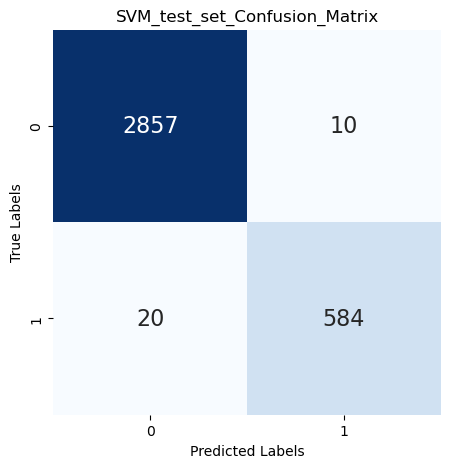

In [89]:
fpr, tpr, _ = roc_curve(y_test, svm_tuned_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(svm_tuned_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM_test_set_Confusion_Matrix')
plt.savefig("SVM_test_set_confusion_matrix.jpg", format="jpg")
plt.show()

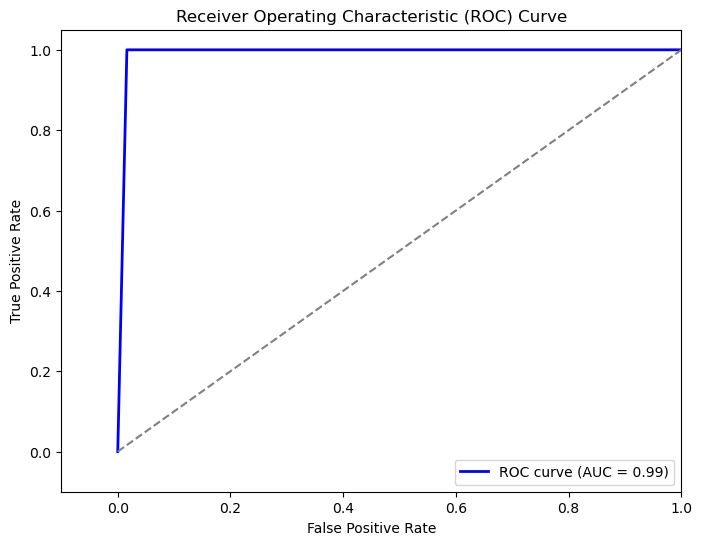

In [107]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("SVM_roc_curve_comparison_test_set.jpg", format="jpg")
plt.show()

# External data validation for svm

In [93]:
# Evaluate the best model
svm_extern_pred = best_svm.predict(df3_filtered)
svm_extern_accuracy = accuracy_score(y1, svm_extern_pred)
from sklearn.metrics import classification_report
svm_extern_report = classification_report(y1, svm_extern_pred)

In [95]:
# Print evaluation results
print("Evaluation Results:")
print(f"Accuracy: {svm_extern_accuracy}")
print("Classification Report:")
print(svm_extern_report)

Evaluation Results:
Accuracy: 0.9842857142857143
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       680
           1       0.65      1.00      0.78        20

    accuracy                           0.98       700
   macro avg       0.82      0.99      0.89       700
weighted avg       0.99      0.98      0.99       700



In [97]:
#confusion matrix of external data set
svm_extern_cm = confusion_matrix(y1,svm_extern_pred)
print(svm_extern_cm)
fpr, tpr, _ = roc_curve(y1, svm_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

[[669  11]
 [  0  20]]


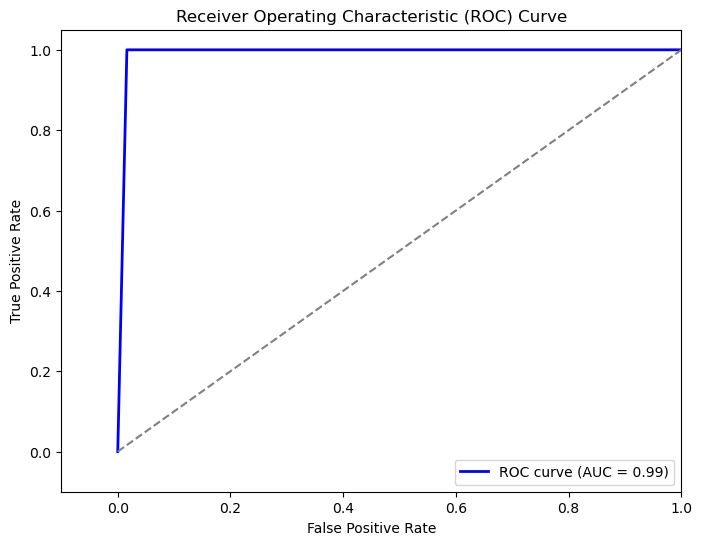

In [99]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("SVM_roc_curve_external_set.jpg", format="jpg")
plt.show()

# Hyperparameter tuning of Random Forest

In [101]:
from sklearn.model_selection import RandomizedSearchCV

In [103]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start = 10, stop = 100, num = 10)],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [int(x) for x in np.linspace(10, 100, num = 10)] + [None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [3, 4, 5],
    'bootstrap': [True, False]
}

In [105]:
# Perform randomized search with 5-fold cross-validation
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=100, cv=cv, scoring='accuracy', verbose=2, 
                                   random_state=42, n_jobs=-1)
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [110]:
# Get best hyperparameters
rf_tuned = random_search.best_params_
print("Best hyperparameters:", rf_tuned)

Best hyperparameters: {'n_estimators': 90, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}


In [112]:
rf_tuned = RandomForestClassifier(n_estimators = 90, min_samples_split = 4, min_samples_leaf = 3, max_features = 'sqrt', max_depth = 20,
                                 bootstrap = False, random_state=42) #hypertuned parameters based on random_search 

In [114]:
rf_tuned.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",90
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [116]:
# Evaluate best model on test set
rf_pred = rf_tuned.predict(x_test)
rf_tuned_accuracy = accuracy_score(y_test, rf_pred)
rf_report = classification_report(y_test, rf_pred)
print("Test accuracy:", rf_tuned_accuracy)

Test accuracy: 0.9916450590607894


In [118]:
rf_tuned_cm = confusion_matrix(y_test,rf_pred)
print(rf_tuned_cm)

[[2855   12]
 [  17  587]]


In [120]:
fpr, tpr, _ = roc_curve(y_test, rf_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

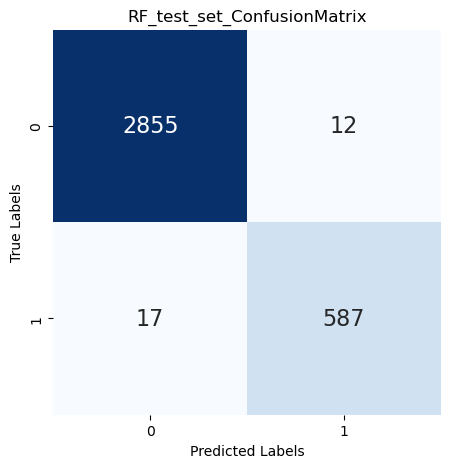

In [122]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(rf_tuned_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('RF_test_set_ConfusionMatrix')
plt.savefig("rf_test_set_confusion_matrix.jpg", format="jpg")
plt.show()

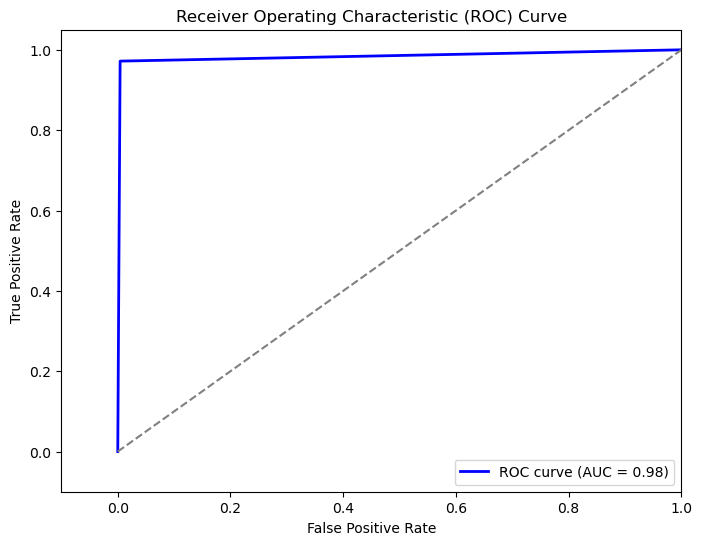

In [124]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("RF_roc_curve_test_set.jpg", format="jpg")
plt.show()

# External data validation of RF

In [126]:
# Evaluate the best model
rf_extern_pred = rf_tuned.predict(df3_filtered)
rf_extern_accuracy = accuracy_score(y1, rf_extern_pred)
from sklearn.metrics import classification_report
rf_extern_report = classification_report(y1, rf_extern_pred)

In [128]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", rf_extern_accuracy)
print("Classification Report:")
print(rf_extern_report)

Evaluation Results:
Accuracy: 0.9842857142857143
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       680
           1       0.65      1.00      0.78        20

    accuracy                           0.98       700
   macro avg       0.82      0.99      0.89       700
weighted avg       0.99      0.98      0.99       700



In [130]:
#confusion matrix of external data set
rf_extern_cm = confusion_matrix(y1,rf_extern_pred)
print(rf_extern_cm)

[[669  11]
 [  0  20]]


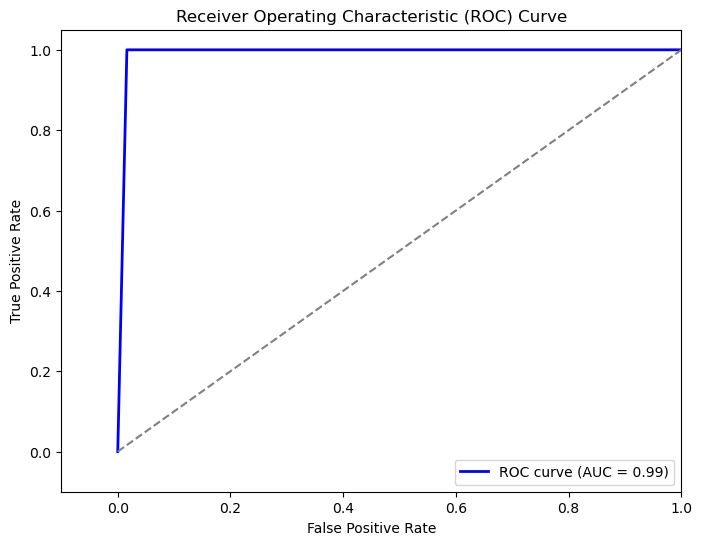

In [132]:
fpr, tpr, _ = roc_curve(y1, rf_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("RF_roc_curve_EXTERNAL_set.jpg", format="jpg")
plt.show()

# Hyperparameter tuning of XGBoost

In [134]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01],
    'gamma': [0, 0.1, 1, 10],
}

In [136]:
# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...state=42, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0, 0.1, ...], 'learning_rate': [0.1, 0.01], 'max_depth': [3, 5]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [138]:
# Get best hyperparameters
best_xgb = grid_search.best_params_
print("Best hyperparameters:", best_xgb)

Best hyperparameters: {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5}


In [140]:
# Get best model
best_xgb = grid_search.best_estimator_
best_xgb = XGBClassifier(gamma= 0.1, learning_rate= 0.1, max_depth= 5) #hypertuned parameter based on grid search
best_xgb.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [142]:
# Evaluate best model on test set
xgb_pred = best_xgb.predict(x_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_report = classification_report(y_test, xgb_pred)

In [144]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", xgb_accuracy)
print("Classification Report:")
print(xgb_report)

Evaluation Results:
Accuracy: 0.9925093632958801
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2867
           1       0.98      0.97      0.98       604

    accuracy                           0.99      3471
   macro avg       0.99      0.99      0.99      3471
weighted avg       0.99      0.99      0.99      3471



In [146]:
xg_tuned_cm = confusion_matrix(y_test,xgb_pred)
print(xg_tuned_cm)

[[2857   10]
 [  16  588]]


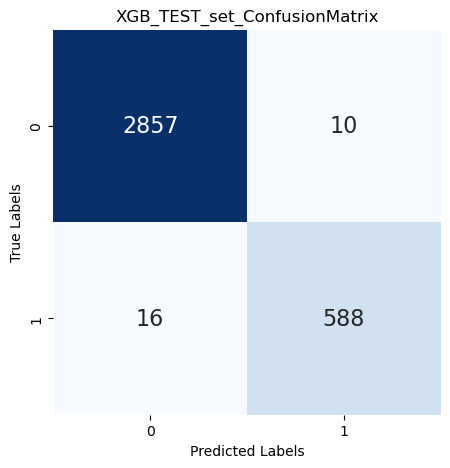

In [160]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(xg_tuned_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('XGB_TEST_set_ConfusionMatrix')
plt.savefig("XGB_TEST_set_confusion_matrix.jpg", format="jpg")
plt.show()

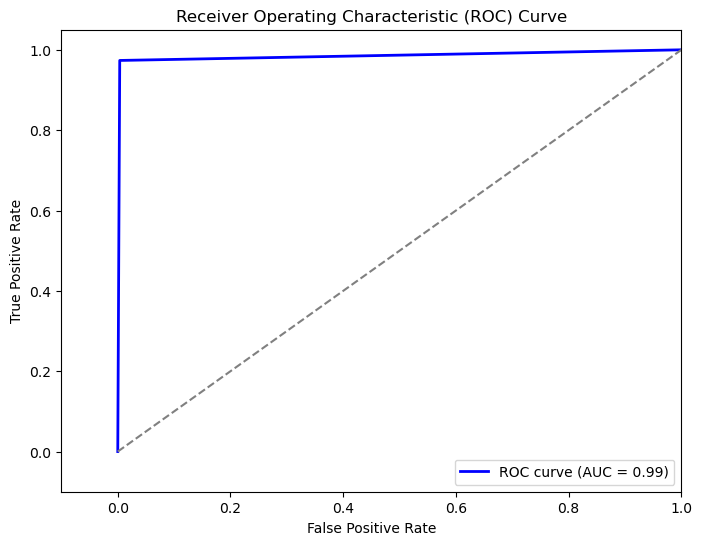

In [150]:
fpr, tpr, _ = roc_curve(y_test, xgb_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("XGB_roc_curve_TEST_set.jpg", format="jpg")
plt.show()

# External Data Validation of XGboost

In [152]:
# Evaluate the best model
xgb_extern_pred = best_xgb.predict(df3_filtered)
xgb_extern_accuracy = accuracy_score(y1, xgb_extern_pred)
from sklearn.metrics import classification_report
xgb_extern_report = classification_report(y1, xgb_extern_pred)

In [154]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", xgb_extern_accuracy)
print("Classification Report:")
print(xgb_extern_report)


Evaluation Results:
Accuracy: 0.9842857142857143
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       680
           1       0.65      1.00      0.78        20

    accuracy                           0.98       700
   macro avg       0.82      0.99      0.89       700
weighted avg       0.99      0.98      0.99       700



In [156]:
#confusion matrix of external data set
xgb_extern_cm = confusion_matrix(y1,xgb_extern_pred)
print(xgb_extern_cm)

[[669  11]
 [  0  20]]


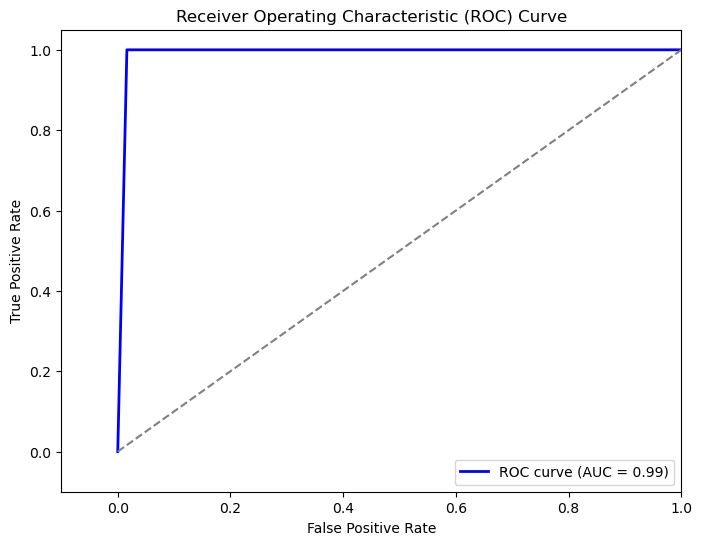

In [158]:
fpr, tpr, _ = roc_curve(y1, xgb_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("XGB_roc_curve_EXTERN_set.jpg", format="jpg")
plt.show()

# Hyperparameter tuning of KNN

In [162]:
# Define hyperparameters grid for tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # Number of neighbors
    'algorithm': ['auto', 'brute'],  # Algorithm used to compute nearest neighbors
    'leaf_size': [10, 20, 30, 40],  
}

In [164]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=2)

In [166]:
# Perform grid search
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['auto', 'brute'], 'leaf_size': [10, 20, ...], 'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [168]:
# Print best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 3}


In [170]:
# Get the best model
#best_knn = grid_search.best_estimator_
knn = KNeighborsClassifier(algorithm = 'auto', leaf_size = 10, n_neighbors = 3)

In [172]:
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",10
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [174]:
# Evaluate the best model
knn_tuned_pred = knn.predict(x_test)
knn_tuned_accuracy = accuracy_score(y_test, knn_tuned_pred)
report = classification_report(y_test, knn_tuned_pred)

In [176]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", knn_tuned_accuracy)
print("Classification Report:")
print(report)

Evaluation Results:
Accuracy: 0.9890521463555172
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2867
           1       0.95      0.99      0.97       604

    accuracy                           0.99      3471
   macro avg       0.98      0.99      0.98      3471
weighted avg       0.99      0.99      0.99      3471



In [178]:
# Assuming y_test is the true labels for your test dataset
knn_tuned_cm = confusion_matrix(y_test, knn_tuned_pred)
print(knn_tuned_cm)

[[2838   29]
 [   9  595]]


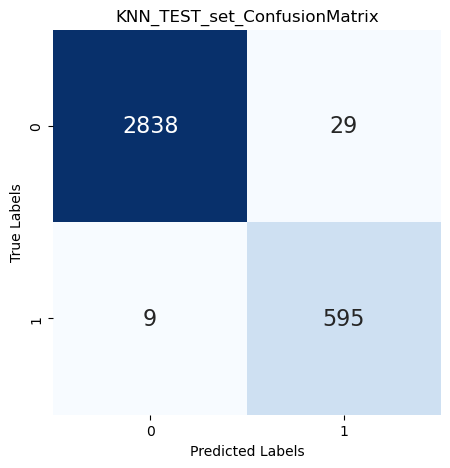

In [180]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(knn_tuned_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('KNN_TEST_set_ConfusionMatrix')
plt.savefig("KNN_TEST_set_confusion_matrix.jpg", format="jpg")
plt.show()

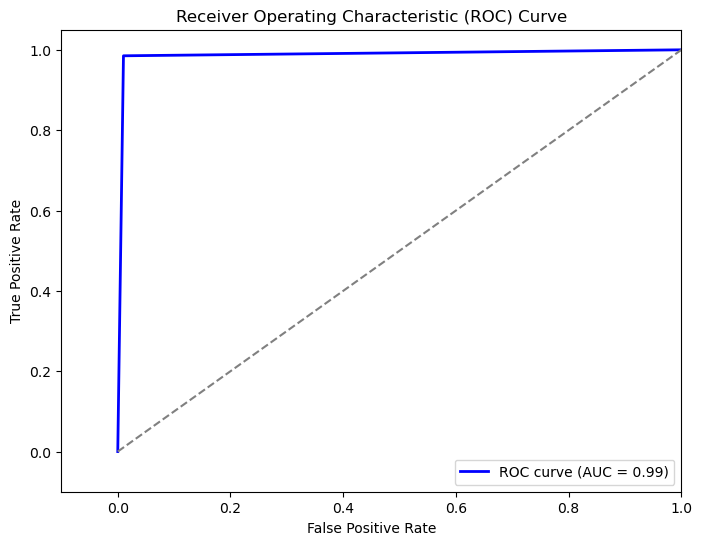

In [182]:
# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, knn_tuned_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("knn_roc_curve_test_set.jpg", format="jpg")
plt.show()

In [184]:
# Evaluate the best model
knn_extern_pred = knn.predict(df3_filtered)
knn_extern_accuracy = accuracy_score(y1, knn_extern_pred)
from sklearn.metrics import classification_report
knn_extern_report = classification_report(y1, knn_extern_pred)# Evaluate the best model

In [186]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", knn_extern_accuracy)
print("Classification Report:")
print(knn_extern_report)

Evaluation Results:
Accuracy: 0.9757142857142858
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       680
           1       0.54      1.00      0.70        20

    accuracy                           0.98       700
   macro avg       0.77      0.99      0.84       700
weighted avg       0.99      0.98      0.98       700



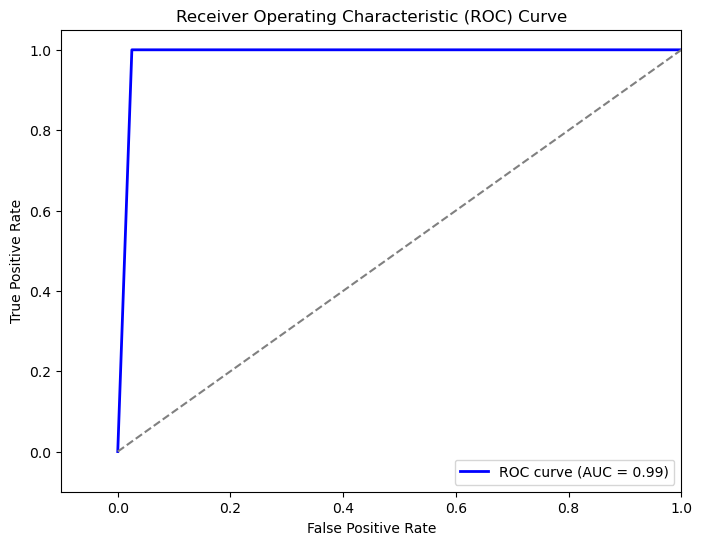

In [188]:
# Calculate ROC curve
fpr, tpr, _ = roc_curve(y1,knn_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.savefig("knn_roc_curve_external_set.jpg", format="jpg")
plt.show()

# KNN Screening of Maybridge Library

In [190]:
#calling screening library in SMILE-csv file
maybridge_liberary = pd.read_csv('MAYBRIDGE_LIBERARY.csv')

In [192]:
knn_screen_predictions = knn.predict(df2_filtered)
maybridge_liberary['knn_pubchem_pred'] = knn_screen_predictions
maybridge_liberary['knn_pubchem_pred'].value_counts()

knn_pubchem_pred
0    54073
1     1643
Name: count, dtype: int64

In [194]:
maybridge_liberary.to_csv('Pubchem_MODEL_prediction.csv', index=False)
data = pd.read_csv('Pubchem_MODEL_prediction.csv')
#extracting the knn actives from the smiles file of screened liberary
active_rows = data[data['knn_pubchem_pred'] == 1]
#creating the separate csv file of actives
active_rows.to_csv('KNN_PUBCHEM_actives.csv', index=False)

# ROC_PLOT of all the models combined: Test set

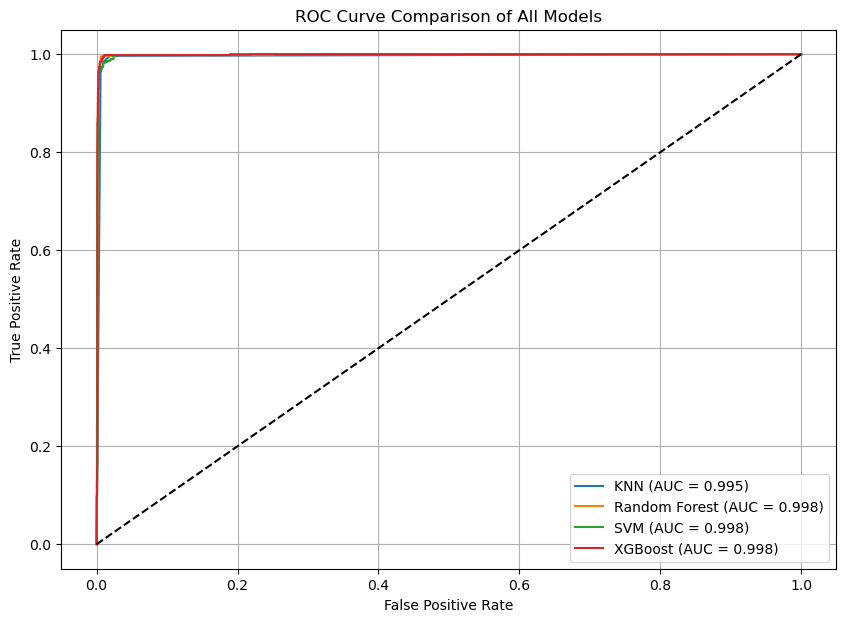

In [196]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------
# KNN (use probability scores)
# -----------------------------
knn_tuned_pred = knn.predict(x_test)
knn_pred_proba = knn.predict_proba(x_test)[:, 1]

fpr_knn_test, tpr_knn_test, _ = roc_curve(y_test, knn_pred_proba)
auc_knn = auc(fpr_knn_test, tpr_knn_test)

# -----------------------------
# Random Forest
# -----------------------------
rf_pred = rf_tuned.predict(x_test)
rf_pred_proba = rf_tuned.predict_proba(x_test)[:, 1]

fpr_rf_test, tpr_rf_test, _ = roc_curve(y_test, rf_pred_proba)
auc_rf = auc(fpr_rf_test, tpr_rf_test)

# -----------------------------
# SVM (requires decision function, not predict_proba)
# -----------------------------
svm_tuned_pred = best_svm.predict(x_test)
svm_scores = best_svm.decision_function(x_test)

fpr_svm_test, tpr_svm_test, _ = roc_curve(y_test, svm_scores)
auc_svm = auc(fpr_svm_test, tpr_svm_test)

# -----------------------------
# XGBoost (use predict_proba)
# -----------------------------
xgb_pred = best_xgb.predict(x_test)
xgb_pred_proba = best_xgb.predict_proba(x_test)[:, 1]

fpr_xgb_test, tpr_xgb_test, _ = roc_curve(y_test, xgb_pred_proba)
auc_xgb = auc(fpr_xgb_test, tpr_xgb_test)

# -----------------------------
# PLOT ALL ROC CURVES TOGETHER
# -----------------------------
plt.figure(figsize=(10, 7))

plt.plot(fpr_knn_test, tpr_knn_test, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot(fpr_rf_test, tpr_rf_test, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_svm_test, tpr_svm_test, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_xgb_test, tpr_xgb_test, label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.title('ROC Curve Comparison of All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
# Save the figure at 900 dpi
#plt.savefig('combine_test_roc_curves.png', dpi=900, bbox_inches='tight')
plt.show()

# ROC_Plot of all the model combined: External Validation set

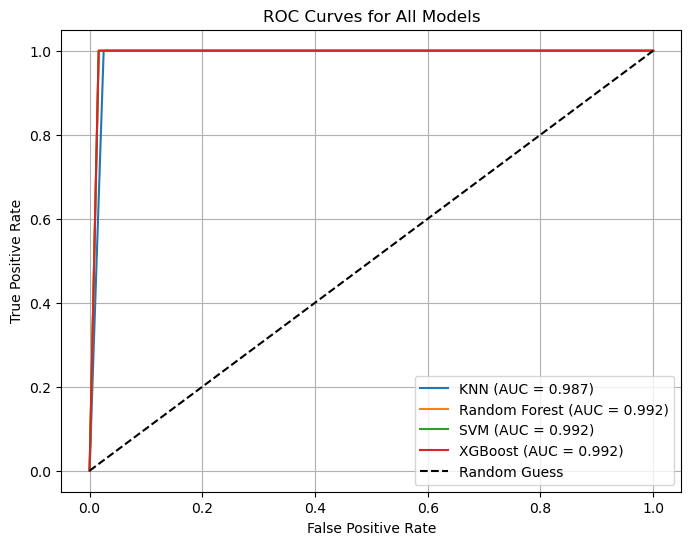

In [198]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------
# KNN
# -----------------------
knn_pred = knn.predict(df3_filtered)
knn_acc = accuracy_score(y1, knn_pred)
knn_report = classification_report(y1, knn_pred)
fpr_knn, tpr_knn, _ = roc_curve(y1, knn_pred)
auc_knn = auc(fpr_knn, tpr_knn)

# -----------------------
# Random Forest
# -----------------------
rf_pred = rf_tuned.predict(df3_filtered)
rf_acc = accuracy_score(y1, rf_pred)
rf_report = classification_report(y1, rf_pred)
fpr_rf, tpr_rf, _ = roc_curve(y1, rf_pred)
auc_rf = auc(fpr_rf, tpr_rf)

# -----------------------
# SVM
# -----------------------
svm_pred = best_svm.predict(df3_filtered)
svm_acc = accuracy_score(y1, svm_pred)
svm_report = classification_report(y1, svm_pred)
fpr_svm, tpr_svm, _ = roc_curve(y1, svm_pred)
auc_svm = auc(fpr_svm, tpr_svm)

# -----------------------
# XGBoost
# -----------------------
xgb_pred = best_xgb.predict(df3_filtered)
xgb_acc = accuracy_score(y1, xgb_pred)
xgb_report = classification_report(y1, xgb_pred)
fpr_xgb, tpr_xgb, _ = roc_curve(y1, xgb_pred)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# ------------------------------------------------------------
# 📈 Plot All ROC Curves Together
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid(True)
# Save the figure at 900 dpi
#plt.savefig('combine_external_roc_curves.png',dpi=900, bbox_inches='tight')
plt.show()